In [65]:
# Header for the notebook
from datetime import datetime
from IPython.display import display, Markdown

# Get the current date
title = "ENMO_00.jpynb"
current_date = datetime.now().strftime("%d %B %Y, %H:%M:%S")
authors = "Jerome Bosc (and Gemini)"

# Insert the date into the notebook
display(Markdown(f"# {title}"))
display(Markdown(f"{current_date}"))
display(Markdown(f"by {authors}"))

# ENMO_00.jpynb

28 September 2026, 16:54:48

by Jerome Bosc (and Gemini)


In this Jupyter notebook:  
- We read raw accelerometer data from a wrist-worn accelerometer (Axivity AX3) worn on the non-dominant wrist.
- We plot ENMO integrated and raw ENMO.  

ENMO (Euclidean Norm Minus One) analyzes physical activity, which is calculated based on data from a 3-axis accelerometer (x, y, and z), by subtracting 1 G (to eliminate the influence of gravity).



# 1. Import required libraries  
We will use numpy and matplotlib for plotting the graphs.


In [66]:
# imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The following magic command enables interactive matplotlib plots using ipywidgets.
# You may need to install 'ipywidgets' and 'ipympl' for this to work.
%matplotlib widget
    

# 2. Load dataset

### Load dataset from raw accelerometer data file

In [67]:
def load_data(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, comment="#")
    df.columns = df.columns.str.strip()
    return df

dataset = load_data('data/0_z.csv')
dataset.head()

,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


# 3. Compute ENMO

## 3.1 Compute raw ENMO   

Prompt to Gemini: How calculate ENMO with Python ?  
It gives me the formula to calulate it : ENMO = $\sqrt{X^2 + Y^2 + Z^2}$ -1   
=> I kept the negative part of the ENMO, even though Gemini suggested that I keep only the values greater than 0, I did this to follow the example graphs provided in the assignment instructions.  


In [68]:
dataset["ENMO"] = np.sqrt(dataset["x"] ** 2 + dataset["y"] ** 2 + dataset["z"] ** 2) - 1
dataset["time_min"] = dataset["t"] / 60.0
dataset.head()

,t,x,y,z,ENMO,time_min
0,0.00,-0.0938,-0.0156,0.9531,-0.042168,0.000000
1,0.02,-0.0938,-0.0156,0.9531,-0.042168,0.000333
2,0.04,-0.0938,-0.0156,0.9531,-0.042168,0.000667
3,0.06,-0.0938,-0.0156,0.9531,-0.042168,0.001000
4,0.08,-0.0938,-0.0156,0.9531,-0.042168,0.001333


## 3.2. Function to compute ENMO integrated  

Prompt to Gemini: Write a Python function to integrate ENMO (in g.min) by epochs of epoch_sec from a DataFrame with t and ENMO.

In [69]:
def integrate_enmo(df: pd.DataFrame, epoch_sec: float) -> pd.DataFrame:
    df_temp = df.copy()

    # Split into blocks (epochs) based on the specified parameter (10s, 30s, 60s)
    df_temp["epoch_group"] = (df_temp["t"] // epoch_sec) * epoch_sec
    # ENMO sum for each block
    # Group all the rows in the table that belong to the same time period
    # .agg => Apply different calculations to different columns at the same time
    integrated = (
        df_temp.groupby("epoch_group")
        .agg(
            time_min=("t", lambda x: x.iloc[0] / 60.0),
            raw_sum=("ENMO", "sum"), 
        )
        .reset_index()
    )
# Multiply by the epoch duration expressed in minutes
    epoch_in_minutes = epoch_sec / 60.0
    integrated["integrated_enmo"] = integrated["raw_sum"] * epoch_in_minutes

    return integrated.drop(columns=["raw_sum"])

# 4. Plot the ENMO  

Two graphs per epoch: ENMO integrated and raw ENMO  

Prompt to Gemini: Write a function to plot 2 subplots for multiple epochs from a dataset with ENMO and time_min. Use integrate_enmo(df, epoch) to get integrated ENMO.  
=> I used the option to share x axis.  
=> I changed the order of the graphs.  
=> I changed integrated["ENMO"] by integrated["integrated_enmo"], I hadn't specified, in the prompt, the name of the column that my function returned  
=> I changed the colors of the graphs to gray and blue.    
=> I changed the 'align' option to 'edge' so that the bars start at the beginning of the time interval.


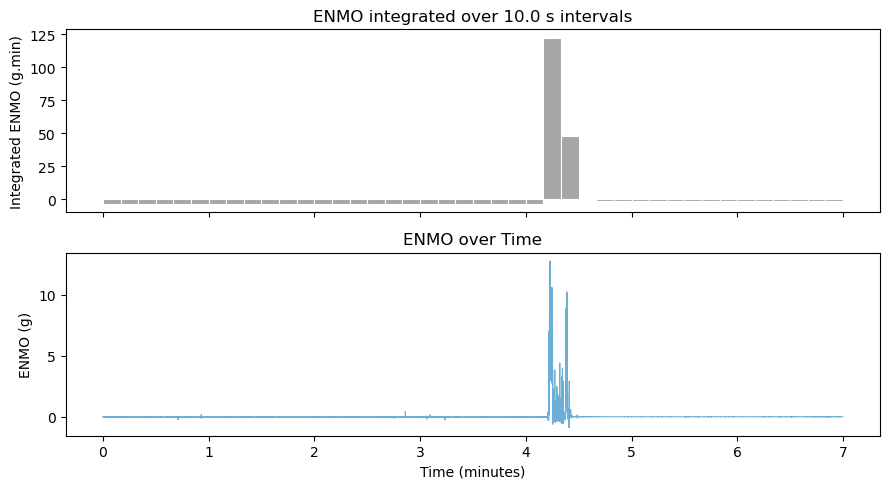

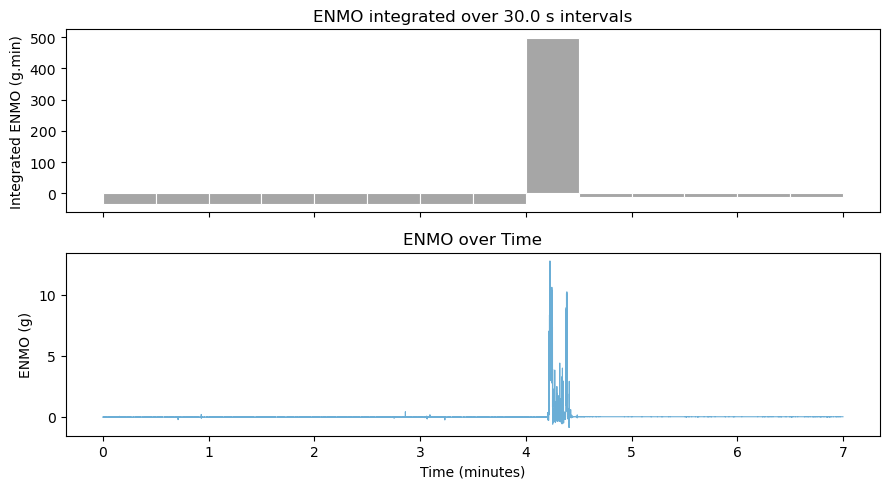

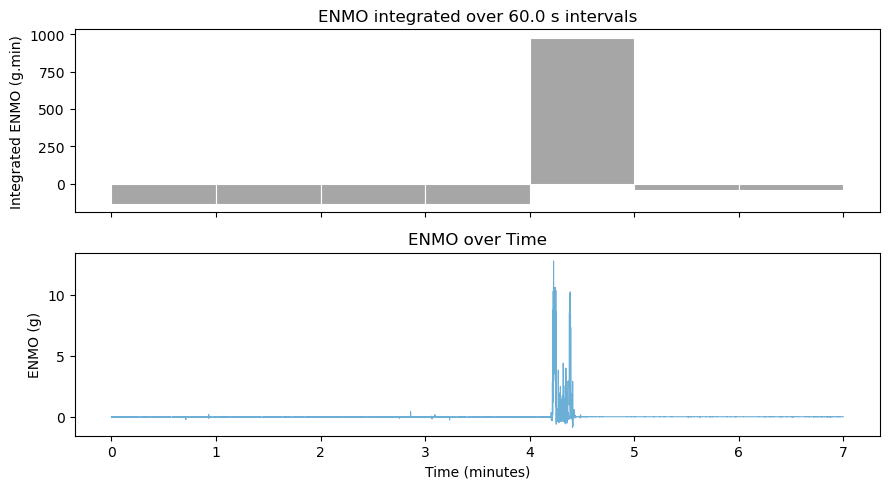

In [73]:
def plot_enmo_for_epochs(df: pd.DataFrame, epochs=[10, 30, 60]):
    for epoch in epochs:
        fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

        integrated = integrate_enmo(df, epoch)
        width_min = epoch / 60.0

        # Graph of ENMO integrated
        axes[0].bar(
            integrated["time_min"],
            integrated["integrated_enmo"],
            width=width_min,
            color="#a6a6a6",
            align="edge",
            edgecolor="white",
            linewidth=0.8,
        )
        axes[0].set_ylabel("Integrated ENMO (g.min)")
        axes[0].set_title(f"ENMO integrated over {float(epoch)} s intervals")
        #axes[0].grid(axis="y", linestyle="--", alpha=0.5)

        # Graph of raw ENMO
        axes[1].plot(
            df["time_min"],
            df["ENMO"],
            color="#6baed6",
            linewidth=0.8,
        )
        axes[1].set_ylabel("ENMO (g)")
        axes[1].set_title("ENMO over Time")
        axes[1].set_xlabel("Time (minutes)")
        #axes[1].grid(axis="y", linestyle="--", alpha=0.5)

        plt.tight_layout()
        plt.show()

plot_enmo_for_epochs(dataset, epochs=[10, 30, 60])


In [71]:
# https://nbconvert.readthedocs.io/en/latest/removing_cells.html
# https://github.com/msm1089/ipynbname/issues/17#issuecomment-1293269863


from traitlets.config import Config
from nbconvert.exporters import HTMLExporter
from nbconvert.preprocessors import TagRemovePreprocessor
from IPython.core.getipython import get_ipython
import os


def get_notebook_name():
    """
    Get the current notebook name (without extension).
    """
    ip = get_ipython()
    path = None
    if "__vsc_ipynb_file__" in ip.user_ns:  # type: ignore
        path = ip.user_ns["__vsc_ipynb_file__"] # type: ignore
        # split the path to get only the file name without extension

    return os.path.splitext(path)[0]  # type: ignore


# Get the notebook name
notebook_file_name = get_notebook_name()

# Switch to inline backend for HTML export (interactive backends don't work in static HTML)
get_ipython().run_line_magic("matplotlib", "inline")  # type: ignore
print("Switched to 'inline' backend for HTML export")


# Setup config
c = Config()

# Configure tag removal - be sure to tag your cells to remove  using the
# words remove_cell to remove cells. You can also modify the code to use
# a different tag word
c.TagRemovePreprocessor.remove_cell_tags = ("remove",)
c.TagRemovePreprocessor.remove_all_outputs_tags = ("remove_output",)
c.TagRemovePreprocessor.remove_input_tags = ("hide",)
c.TagRemovePreprocessor.enabled = True
c.HTMLExporter.preprocessors = ["nbconvert.preprocessors.TagRemovePreprocessor"]

# ensure the graphics are included in the html
c.HTMLExporter.embed_images = True
# do not show the input code cells (distracts from the output)
c.HTMLExporter.exclude_output_prompt = True
c.HTMLExporter.exclude_input_prompt = True

# Configure the exporter
exporter = HTMLExporter(config=c)
exporter.register_preprocessor(TagRemovePreprocessor(config=c), True)


# run our exporter - returns a tuple - first element with html,
# second with notebook metadata
output = HTMLExporter(config=c).from_filename(notebook_file_name + ".ipynb")

# Write to output html file
with open(notebook_file_name + ".html", "w") as f:
    f.write(output[0])

# open the file with the operating system's default program
# handle spaces in filename with quotes
try:
    if os.name == "posix":
        if os.uname().sysname == "Darwin":
            # macOS - use single quotes for spaces
            os.system(f"open '{notebook_file_name}.html'")
        else:
            # Linux - use single quotes for spaces
            os.system(f"xdg-open '{notebook_file_name}.html'")
    elif os.name == "nt":
        # Windows - use double quotes for empty title + for file name with spaces
        os.system(f'start "" "{notebook_file_name}.html"')
    else:
        print("Unsupported OS")
except Exception as e:
    print("Error opening file: ", e)


Switched to 'inline' backend for HTML export
